# 🎯 MediaPipe for Researchers & Practitioners

**A Hands-On Workshop**

---

## Workshop Overview

| Section | Duration | Content |
|---------|----------|--------|
| **Introduction** | 14 min | What is MediaPipe, why use it, capabilities overview |
| **Hands-On Examples** | 32 min | Computer vision, NLP, and audio analysis |
| **Conclusion** | 7 min | Recap, next steps, and resources |

**Prerequisites:**
- Basic Python knowledge
- No machine learning background required

---

# Part 1: Introduction

---

## 1.1 What is MediaPipe?

### Simple Definition

**MediaPipe** is a free, open-source toolkit from Google that lets you add AI capabilities to your applications **without needing to understand the underlying machine learning**.

### An Analogy

> 💡 Think of MediaPipe like a **plug-and-play AI system**. Just as you don't need to understand electricity to use a lamp, you don't need to understand neural networks to use MediaPipe.

### What It Actually Does

MediaPipe provides **ready-to-use solutions** for common tasks:

- 👁️ **Detecting faces, hands, and body poses** in images and videos
- 🔍 **Recognizing objects** in visual content
- 📝 **Analyzing text sentiment** (positive/negative/neutral)
- 🔊 **Classifying audio** (speech, music, environmental sounds)

### The Key Insight

> Google's researchers already did the hard work of training sophisticated AI models. **MediaPipe packages these models so anyone can use them with just a few lines of code.**

---

**Terminology note:** When we say "model" in this workshop, we simply mean *a trained AI system that learned patterns from thousands of examples*. You don't need to understand how it works inside—just how to use it.

## 1.2 Why MediaPipe?

### Four Key Advantages for Researchers

---

### ✅ 1. Free and Open Source

- **No licensing costs**, no subscription fees
- Can be used in academic research **without budget concerns**
- Published research can be **replicated by others** without paywall issues

**Compare with alternatives:**
| Service | Cost |
|---------|------|
| Amazon Rekognition | ~\$1 per 1,000 images |
| Google Cloud Vision API | ~\$1.50 per 1,000 images |
| **MediaPipe** | **Free** |

---

### ✅ 2. Simpler Than Other Frameworks

**The alternative approach:**
- Building your own AI system requires **months of work**, expensive hardware, and deep expertise
- Other frameworks like TensorFlow or PyTorch require you to **understand machine learning concepts**

**The MediaPipe approach:**
- MediaPipe **abstracts away the complexity**
- You give it an image → It gives you results

> 💡 **Analogy:** It's like the difference between assembling furniture from raw lumber vs. buying from IKEA.

---

### ✅ 3. Pretrained Models Available

**What does "pretrained" mean?**
- The AI has **already learned from millions of examples** (images, texts, audio clips)
- You don't need your own training data to get started
- You don't need expensive GPUs to train models

**The models work out-of-the-box** for common use cases.

*(Advanced users can fine-tune with their own data later, but that's beyond today's scope.)*

---

### ✅ 4. Many Models Run Locally (On Your Computer)

This has important implications:

| Benefit | Why It Matters |
|---------|---------------|
| 🔒 **Privacy** | Your data never leaves your computer—critical for sensitive research (medical images, private interviews) |
| 📴 **Offline** | Can process data without internet—useful for fieldwork |
| 💰 **Cost** | No cloud computing costs after initial setup |
| ⚡ **Speed** | No network latency, faster processing |
| 🔄 **Reproducibility** | Results don't depend on a remote service that might change |

## 1.3 Overview of Capabilities

MediaPipe is a **toolkit**—you pick the specific capability you need for your research question.

---

### 👁️ Computer Vision (What AI Can "See")

| Capability | Description | Research Applications |
|------------|-------------|----------------------|
| **Face Detection** | Locate faces in images/video | Emotion research, attention studies |
| **Face Mesh** | 468 points tracking facial features | Expression analysis, animation |
| **Hand Detection** | 21 landmark points per hand | Gesture analysis, sign language research |
| **Pose Estimation** | 33 body landmarks | Sports science, physical therapy, ergonomics |
| **Object Detection** | Identify common objects | Content analysis, accessibility |
| **Image Segmentation** | Separate foreground/background | Video production, visual analysis |

---

### 📝 Natural Language Processing (What AI Can "Read")

| Capability | Description | Research Applications |
|------------|-------------|----------------------|
| **Sentiment Analysis** | Positive/negative/neutral | Social media analysis, survey coding |
| **Text Classification** | Categorize text by topic | Content analysis, document sorting |
| **Language Detection** | Identify language | Multilingual research |

---

### 🔊 Audio Analysis (What AI Can "Hear")

| Capability | Description | Research Applications |
|------------|-------------|----------------------|
| **Audio Classification** | Identify sound types | Interview analysis, environmental studies |
| **Speech Detection** | Detect when speech occurs | Conversation analysis, media research |

## 1.4 Interactive Exercise: MediaPipe Studio

---

### 🎮 Try It Without Writing Any Code!

MediaPipe Studio is a **web-based interface** where you can experiment with all MediaPipe capabilities before writing code.

## 👉 [Open MediaPipe Studio](https://mediapipe-studio.webapps.google.com/home)

---

### Guided Exploration (3 minutes)

1. Click on **"Hand Landmark Detection"**
2. Allow camera access (or upload an image)
3. Wave your hand in front of the camera
4. Notice:
   - The colored dots on your hand joints (landmarks)
   - The lines connecting the landmarks
   - The confidence score showing how certain the AI is

---

### Free Exploration (3 minutes)

Try these demos:
- 🎭 **Face Mesh** — See 468 points tracked on your face
- 🏃 **Pose Detection** — Stand up and see your body landmarks
- 📦 **Object Detection** — Point your camera at objects around you
- 😍 **Sentiment Analysis** - Play around with your textual input

---

### 💭 Reflection Question

> **How might these capabilities apply to your research?**

---

# Part 2: Hands-On Examples

---

Now let's see how to use MediaPipe programmatically. We'll cover:

1. **Computer Vision**: Hand detection in images and videos
2. **Natural Language Processing**: Sentiment analysis
3. **Bonus**: Audio classification (time permitting)

## 2.0 Setup: Installing MediaPipe

First, let's install the required packages. Run this cell once at the beginning.

In [1]:
# Install required packages
# Run this cell once - it may take a minute or two

!pip install -q mediapipe opencv-python matplotlib numpy Pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.2 MB/s eta 0:00:00


In [2]:
# Import common libraries we'll use throughout
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import urllib.request
import os
import requests
from tqdm import tqdm

# Configure matplotlib for notebook display
plt.rcParams['figure.figsize'] = [12, 8]

print("✅ All libraries imported successfully!")
print(f"MediaPipe version: {mp.__version__}")

✅ All libraries imported successfully!
MediaPipe version: 0.10.32


## 2.1 Computer Vision: Detecting Hands

---

### What We're Doing

Given an image or video, we will:
- **Identify where hands are located**
- **Track 21 specific points** on each hand (fingertips, knuckles, wrist)
- **Determine handedness** (left or right)

### Why This Matters for Research

- 🤟 **Sign language research** — Track hand shapes and movements
- 🎮 **Human-computer interaction** — Gesture recognition studies
- 🏭 **Occupational safety** — Analyze hand positions in workplaces
- ⚽ **Sports analysis** — Technique analysis in sports like basketball, tennis

#### The 21 Hand Landmarks

MediaPipe tracks these specific points on each hand:

```
        8   12  16  20       ← Fingertips
        |   |   |   |
        7   11  15  19
        |   |   |   |
        6   10  14  18
        |   |   |   |
        5   9   13  17
         \  |   |  /
    4     \ |   | /
    |      \|   |/
    3       2   1
    |        \ /
    2         0  ← Wrist
    |
    1
```

- **0**: Wrist
- **1-4**: Thumb
- **5-8**: Index finger
- **9-12**: Middle finger
- **13-16**: Ring finger
- **17-20**: Pinky

### Step 1: Download Sample Images

We'll use some sample images for our examples.

In [3]:
# Download sample hand images (using MediaPipe's own sample images)

image_paths = [
    "https://raw.githubusercontent.com/valeriolagatta/rdcs_mediapipe_workshop/main/hands/hand_intro.jpg",
    "https://raw.githubusercontent.com/valeriolagatta/rdcs_mediapipe_workshop/main/hands/hand_2hands.jpg",
    "https://raw.githubusercontent.com/valeriolagatta/rdcs_mediapipe_workshop/main/hands/hand_manyhands.png",
]


for hand_image_path in image_paths:
    response = requests.get(hand_image_path)

    with open(hand_image_path.split("/")[-1], "wb") as f:
        f.write(response.content)

print("\n📁 Sample images downloaded with success!")


📁 Sample images downloaded with success!


In [5]:
images_paths = [
    "hand_intro.jpg",
    "hand_2hands.jpg",
    "hand_manyhands.png"
]

hand_image_path = images_paths[0]

### Step 2: Load and Display the Original Image

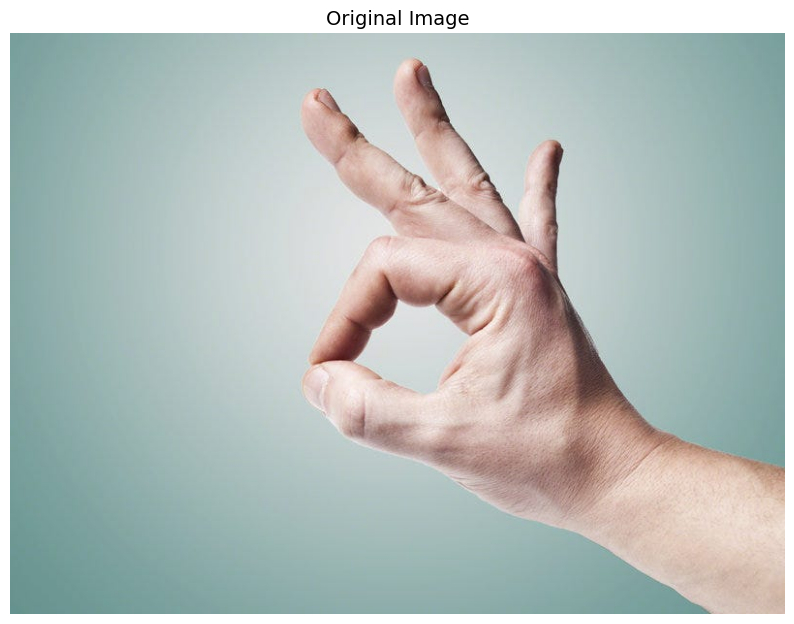

Image size: 800 x 600 pixels


In [6]:
# Load the image
# Read image from the filesystem
image = cv2.imread(hand_image_path)

# Convert from BGR (OpenCV format) to RGB (display format)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the original image
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.title("Original Image", fontsize=14)
plt.axis('off')
plt.show()

print(f"Image size: {image.shape[1]} x {image.shape[0]} pixels")

### Step 3: Set Up the Hand Detector

Now we'll load MediaPipe's hand detection model. This is where the "magic" happens—we're loading a pretrained AI model that has already learned to recognize hands from millions of examples.

When we create the hand detector, we configure it with several options that control how it behaves:

| Option | Value | Modality | What It Does |
|--------|-------|-------|--------------|
| `num_hands` | 2 | Image \& Video | Maximum number of hands to detect. Increase if analyzing group images; decrease to 1 for faster processing when you only expect one hand. |
| `min_hand_detection_confidence` | 0.5 | Image \& Video | How confident the model must be to initially detect a hand (0.0 to 1.0). Lower values catch more hands but may include false positives. |
| `min_hand_presence_confidence` | 0.5 | Video-only | How confident the model must be that a hand is still present in subsequent frames. More relevant for video than static images. |
| `min_tracking_confidence` | 0.5 | Video-only | How confident the model must be to continue tracking landmarks on a detected hand. Higher values give more stable but potentially fewer results. |

**When to adjust these values:**

- **Increase confidence thresholds (e.g., 0.7)** when you need high precision and want to avoid false detections
- **Decrease confidence thresholds (e.g., 0.3)** when you want to catch more hands, even at the risk of some errors
- **Set `num_hands` higher** if analyzing images with multiple people (e.g., group photos, crowds)

In [7]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

# Download the hand landmarker model
model_url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
model_path = "models/hand_landmarker.task"

os.makedirs('models', exist_ok=True)
if not os.path.exists(model_path):
    print("Downloading hand landmarker model...")
    urllib.request.urlretrieve(model_url, model_path)
    print(f"✅ Model saved to {model_path}")

# Create the hand detector with the new API
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
detector = vision.HandLandmarker.create_from_options(options)

print("✅ Hand detector ready!")

✅ Model saved to models/hand_landmarker.task
✅ Hand detector ready!


### Step 4: Run Hand Detection

Now we pass our image to the detector and get back the results.

In [8]:
# Load image using MediaPipe's format
mp_image = mp.Image.create_from_file(hand_image_path)

# Detect hands
results = detector.detect(mp_image)

# Check results
if results.hand_landmarks:
    print(f"Detected {len(results.hand_landmarks)} hand(s)")
else:
    print("No hands detected")

Detected 1 hand(s)


### Step 5: Visualize the Results

Let's draw the detected landmarks on the image so we can see what the AI found.

#### Visualisation Utilities

In [9]:
#@markdown We implemented some functions to visualize the hand landmark detection results. <br/> Run the following cell to activate the functions.
import mediapipe as mp
import numpy as np

mp_hands = mp.tasks.vision.HandLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

MARGIN = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
HANDEDNESS_TEXT_COLOR = (88, 205, 54) # vibrant green

def draw_landmarks_on_image(rgb_image, detection_result):
  hand_landmarks_list = detection_result.hand_landmarks
  handedness_list = detection_result.handedness
  annotated_image = np.copy(rgb_image)

  # Loop through the detected hands to visualize.
  for idx in range(len(hand_landmarks_list)):
    hand_landmarks = hand_landmarks_list[idx]
    handedness = handedness_list[idx]

    # Draw the hand landmarks.
    mp_drawing.draw_landmarks(
      annotated_image,
      hand_landmarks,
      mp_hands.HAND_CONNECTIONS,
      mp_drawing_styles.get_default_hand_landmarks_style(),
      mp_drawing_styles.get_default_hand_connections_style())

    # Get the top left corner of the detected hand's bounding box.
    height, width, _ = annotated_image.shape
    x_coordinates = [landmark.x for landmark in hand_landmarks]
    y_coordinates = [landmark.y for landmark in hand_landmarks]
    text_x = int(min(x_coordinates) * width)
    text_y = int(min(y_coordinates) * height) - MARGIN

    # Draw handedness (left or right hand) on the image.
    cv2.putText(annotated_image, f"{handedness[0].category_name}",
                (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX,
                FONT_SIZE, HANDEDNESS_TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)

  return annotated_image

#### Visualise the results

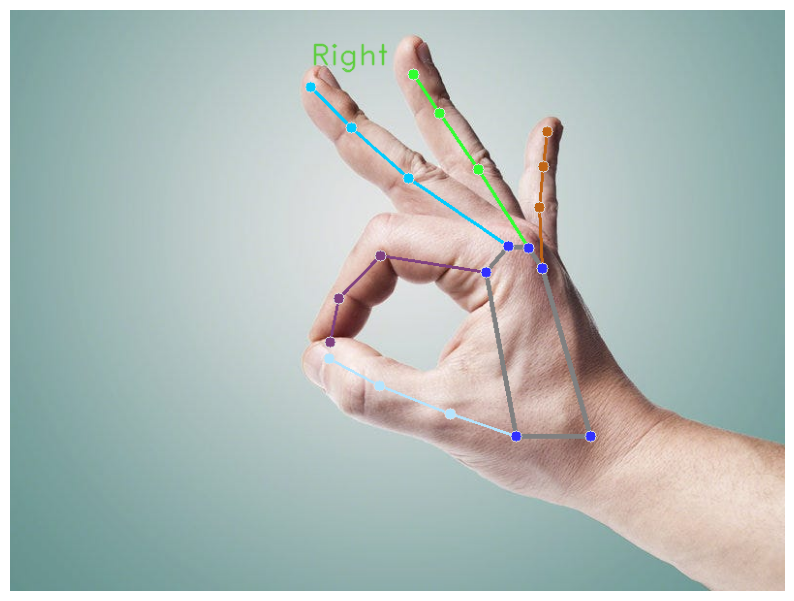

In [10]:
annotated_image = draw_landmarks_on_image(image_rgb, results,)
plt.figure(figsize=(10, 8))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

### Step 6: Access Individual Landmark Coordinates

For research purposes, you'll often want to extract the actual coordinates of each landmark. Here's how to access that data.

In [11]:
if results.hand_landmarks:
    print(f"✅ Detected {len(results.hand_landmarks)} hand(s)!\n")

    # Landmark names for reference
    landmark_names = [
        "WRIST",
        "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
        "INDEX_FINGER_MCP", "INDEX_FINGER_PIP", "INDEX_FINGER_DIP", "INDEX_FINGER_TIP",
        "MIDDLE_FINGER_MCP", "MIDDLE_FINGER_PIP", "MIDDLE_FINGER_DIP", "MIDDLE_FINGER_TIP",
        "RING_FINGER_MCP", "RING_FINGER_PIP", "RING_FINGER_DIP", "RING_FINGER_TIP",
        "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP"
    ]

    for hand_idx, hand in enumerate(results.hand_landmarks):
        # Get handedness if available
        if results.handedness and hand_idx < len(results.handedness):
            hand_label = results.handedness[hand_idx][0].category_name
            hand_score = results.handedness[hand_idx][0].score
            print(f"{'='*50}")
            print(f"HAND {hand_idx + 1}: {hand_label} ({hand_score:.1%} confidence)")
            print(f"{'='*50}")
        else:
            print(f"{'='*50}")
            print(f"HAND {hand_idx + 1}")
            print(f"{'='*50}")

        print(f"{'Landmark':<25} {'X':>8} {'Y':>8} {'Z':>10}")
        print(f"{'-'*53}")

        for lm_idx, landmark in enumerate(hand):
            name = landmark_names[lm_idx] if lm_idx < len(landmark_names) else f"POINT_{lm_idx}"
            print(f"{name:<25} {landmark.x:>8.4f} {landmark.y:>8.4f} {landmark.z:>10.6f}")

        print()  # Blank line between hands
else:
    print("❌ No hands detected in the image")

✅ Detected 1 hand(s)!

HAND 1: Right (88.6% confidence)
Landmark                         X        Y          Z
-----------------------------------------------------
WRIST                       0.7491   0.7334   0.000000
THUMB_CMC                   0.6528   0.7346  -0.092217
THUMB_MCP                   0.5676   0.6952  -0.141353
THUMB_IP                    0.4763   0.6476  -0.168440
THUMB_TIP                   0.4124   0.6013  -0.188819
INDEX_FINGER_MCP            0.6140   0.4519  -0.140024
INDEX_FINGER_PIP            0.4787   0.4236  -0.168617
INDEX_FINGER_DIP            0.4243   0.4976  -0.179103
INDEX_FINGER_TIP            0.4129   0.5725  -0.181712
MIDDLE_FINGER_MCP           0.6427   0.4068  -0.092212
MIDDLE_FINGER_PIP           0.5143   0.2909  -0.123759
MIDDLE_FINGER_DIP           0.4406   0.2037  -0.139267
MIDDLE_FINGER_TIP           0.3881   0.1338  -0.153405
RING_FINGER_MCP             0.6700   0.4109  -0.044095
RING_FINGER_PIP             0.6040   0.2756  -0.068476
RING_FINGE

### Complete Example: A Reusable Function

Here's a complete function you can reuse in your own projects.

In [13]:
def detect_hands_in_image(image_path, show_plot=True):
    """
    Detect hands in an image and return the results.

    Parameters:
    -----------
    image_path : str
        Path to the image file
    show_plot : bool
        Whether to display the annotated image

    Returns:
    --------
    dict : Dictionary containing detection results
    """
    # Load image using MediaPipe's format
    mp_image = mp.Image.create_from_file(image_path)

    # Also load with OpenCV for visualization and dimensions
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape

    # Run detection (using the detector we created earlier)
    results = detector.detect(mp_image)

    # Prepare output
    output = {
        'image_path': image_path,
        'hands_detected': 0,
        'hands': []
    }

    if results.hand_landmarks:
        output['hands_detected'] = len(results.hand_landmarks)

        for idx, landmarks in enumerate(results.hand_landmarks):
            # Get handedness info
            if results.handedness and idx < len(results.handedness):
                hand_type = results.handedness[idx][0].category_name
                confidence = results.handedness[idx][0].score
            else:
                hand_type = "Unknown"
                confidence = 0.0

            hand_data = {
                'hand_type': hand_type,
                'confidence': confidence,
                'landmarks': []
            }

            for lm in landmarks:
                hand_data['landmarks'].append({
                    'x': int(lm.x * w),
                    'y': int(lm.y * h),
                    'z': lm.z
                })

            output['hands'].append(hand_data)

        # Draw annotations
        if show_plot:
            annotated = image_rgb.copy()

            # Draw landmarks manually (new API doesn't have built-in drawing)
            for hand_landmarks in results.hand_landmarks:
                # Draw connections
                connections = [
                    (0, 1), (1, 2), (2, 3), (3, 4),           # Thumb
                    (0, 5), (5, 6), (6, 7), (7, 8),           # Index
                    (0, 9), (9, 10), (10, 11), (11, 12),      # Middle
                    (0, 13), (13, 14), (14, 15), (15, 16),    # Ring
                    (0, 17), (17, 18), (18, 19), (19, 20),    # Pinky
                    (5, 9), (9, 13), (13, 17)                 # Palm
                ]

                # Draw lines
                for start_idx, end_idx in connections:
                    start = hand_landmarks[start_idx]
                    end = hand_landmarks[end_idx]
                    start_pt = (int(start.x * w), int(start.y * h))
                    end_pt = (int(end.x * w), int(end.y * h))
                    cv2.line(annotated, start_pt, end_pt, (0, 255, 0), 2)

                # Draw landmark points
                for lm in hand_landmarks:
                    cx, cy = int(lm.x * w), int(lm.y * h)
                    cv2.circle(annotated, (cx, cy), 5, (255, 0, 0), -1)

            plt.figure(figsize=(10, 8))
            plt.imshow(annotated)
            plt.title(f"Detected {output['hands_detected']} hand(s)")
            plt.axis('off')
            plt.show()

    return output



## 📝 Exercise 1: Apply Hand Detection to Different Images (6 minutes)

Now it's your turn! Let's download some different images and see how the hand detector performs.

### Your Tasks:
1. Run the detection on each image
2. Observe: What works? What doesn't?
3. Think about: How might image quality affect your research?

In [14]:
# Let's create some simple test images with different hand positions
# We'll use placeholder images for the exercise

# For this exercise, we'll provide instructions to use your own images
print("="*60)
print("EXERCISE: Test Hand Detection on Your Own Images")
print("="*60)


EXERCISE: Test Hand Detection on Your Own Images


In [ ]:
# Test the function
my_image_path = ...

result = detect_hands_in_image(my_image_path)
print(f"\nFunction returned: {result['hands_detected']} hand(s) detected")
if result:
    from pprint import pprint
    pprint(result)

### 💭 Discussion Questions

After trying different images, consider:

1. **Did the detector work on images with different skin tones?** (This is an important research consideration)
2. **What happened with partially visible hands?**
3. **How did image quality (blur, lighting) affect results?**
4. **Were there any false positives (hands detected where there weren't any)?**

---

## 2.2 Natural Language Processing: Sentiment Analysis
---

### What We're Doing

Given a piece of text, we will determine if it expresses:
- **Positive** sentiment 😊
- **Negative** sentiment 😞
- **Neutral** sentiment 😐

### Why This Matters for Research

- 📱 **Social media analysis** — Understand public opinion on topics
- 📊 **Survey analysis** — Automatically code open-ended responses
- 🎙️ **Interview transcripts** — Identify emotional segments
- 📰 **Content analysis** — Analyze tone of news articles or reviews

### Important Caveat

> ⚠️ **Sentiment analysis is not perfect!** It's a starting point, not a final answer. Always validate results, especially for research publications.

### Step 1: Download the Sentiment Analysis Model

MediaPipe's text classification requires downloading a model file first.

In [16]:
# Create models directory
os.makedirs('models', exist_ok=True)

# Download the text classifier model
model_url = "https://storage.googleapis.com/mediapipe-models/text_classifier/bert_classifier/float32/1/bert_classifier.tflite"
model_path = "models/bert_classifier.tflite"

if not os.path.exists(model_path):
    print("Downloading sentiment analysis model...")
    print("(This may take a minute - the model is about 25MB)")
    urllib.request.urlretrieve(model_url, model_path)
    print(f"✅ Model saved to {model_path}")
else:
    print(f"✅ Model already exists at {model_path}")

(This may take a minute - the model is about 25MB)
✅ Model saved to models/bert_classifier.tflite


### Step 2: Set Up the Text Classifier

In [17]:
from mediapipe.tasks import python
from mediapipe.tasks.python import text

# Create the text classifier
base_options = python.BaseOptions(model_asset_path=model_path)
options = text.TextClassifierOptions(base_options=base_options)
classifier = text.TextClassifier.create_from_options(options)

print("✅ Sentiment analyzer ready!")

✅ Sentiment analyzer ready!


### Step 3: Analyze a Single Text

In [18]:
# Let's analyze a clearly positive text
sample_text = "I absolutely love this product! It exceeded all my expectations."

# Run the analysis
result = classifier.classify(sample_text)

# Display results
print(f"Text: \"{sample_text}\"")
print("\nSentiment Analysis Results:")
print("-" * 40)

for category in result.classifications[0].categories:
    sentiment = category.category_name
    score = category.score
    bar = "█" * int(score * 20)
    print(f"{sentiment:10} {bar} {score:.1%}")

Text: "I absolutely love this product! It exceeded all my expectations."

Sentiment Analysis Results:
----------------------------------------
positive   ███████████████████ 100.0%
negative    0.0%


### Step 4: Compare Different Types of Text

In [19]:
# Test with different sentiments
test_texts = [
    # Clearly positive
    "This made my day so much better! I'm really happy with the results.",

    # Clearly negative
    "This was a complete waste of time. I'm very disappointed.",

    # Neutral/factual
    "The meeting is scheduled for Tuesday at 3pm in the conference room.",

    # Ambiguous/mixed
    "Well, that was interesting... I'm not sure what to think.",

    # Sarcasm (often challenging for AI)
    "Oh great, another meeting. Just what I needed today."
]

print("Sentiment Analysis of Multiple Texts")
print("=" * 70)

for i, text_sample in enumerate(test_texts, 1):
    result = classifier.classify(text_sample)

    # Get the top prediction
    categories = result.classifications[0].categories
    top_category = max(categories, key=lambda x: x.score)

    # Format output
    print(f"\n[{i}] \"{text_sample[:60]}{'...' if len(text_sample) > 60 else ''}\"")
    print(f"    → {top_category.category_name.upper()} ({top_category.score:.1%} confidence)")

Sentiment Analysis of Multiple Texts

[1] "This made my day so much better! I'm really happy with the r..."
    → POSITIVE (100.0% confidence)

[2] "This was a complete waste of time. I'm very disappointed."
    → NEGATIVE (99.9% confidence)

[3] "The meeting is scheduled for Tuesday at 3pm in the conferenc..."
    → POSITIVE (57.4% confidence)

[4] "Well, that was interesting... I'm not sure what to think."
    → NEGATIVE (75.7% confidence)

[5] "Oh great, another meeting. Just what I needed today."
    → POSITIVE (93.2% confidence)


### Complete Example: A Reusable Function


In [22]:
# Utility function

def analyze_sentiment(text_sample):
    """
    Analyze sentiment of a single text.

    Returns:
    --------
    dict : Dictionary with sentiment label and scores
    """
    result = classifier.classify(text_sample)
    categories = result.classifications[0].categories

    # Create a dictionary of scores
    scores = {cat.category_name: cat.score for cat in categories}

    # Get top prediction
    top_category = max(categories, key=lambda x: x.score)

    return {
        'text': text_sample,
        'sentiment': top_category.category_name,
        'confidence': top_category.score,
        'all_scores': scores
    }

## 📝 Exercise 2: Apply Sentiment Analysis to Social Network Data

In this exercise, we will see how to extract sentiment from social media data. We will also evaluate classification performance of the MediaPipe model.

### Utility Functions

In [23]:

import re
import string

def clean_tweet(tweet):
    """
    Cleans a tweet by removing URLs, mentions, hashtag symbols,
    punctuation, and converting to lowercase.
    """
    # Convert to lowercase
    tweet = tweet.lower()

    # Remove URLs (http/https)
    tweet = re.sub(r"http\S+|https\S+|www\S+", '', tweet, flags=re.MULTILINE)

    # Remove user mentions (@users)
    tweet = re.sub(r"@[A-Za-z0-9_]+", '', tweet)

    # Remove hashtag symbol (#), but keep the text
    tweet = re.sub(r"#", "", tweet)

    # Remove punctuation
    tweet = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', tweet)

    # Remove retweet artifact 'RT'
    tweet = re.sub(r'\brt\b', '', tweet).strip()

    # Remove extra whitespace
    tweet = " ".join(tweet.split())

    return tweet

### Solving the task

In [24]:
# download and read the dataset with annotated tweets

import pandas as pd

df_tweets = pd.read_csv("https://raw.githubusercontent.com/valeriolagatta/rdcs_mediapipe_workshop/main/social_data/df_tweets.csv",)
df_tweets = df_tweets[['textID','text','sentiment']]
df_tweets.columns = ['id','tweet','label']
print(df_tweets.shape)
df_tweets.head()

(27481, 3)


,id,tweet,label
0,cb774db0d1,"I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative
2,088c60f138,my boss is bullying me...,negative
3,9642c003ef,what interview! leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative


In [25]:
# sample 100 tweets from the dataset (for demonstration only)

df_tweets = df_tweets[df_tweets.label.isin(['positive','negative'])]
df_tweets = df_tweets.sample(n=100, random_state=100)
print(df_tweets.shape)
df_tweets.head()


(100, 3)


,id,tweet,label
5057,57d2d26a40,Meeeee! It sounds delicious,positive
19195,7d73cedc31,Happy Mother`s Day to all the moms out there! ...,positive
17479,cd3b1a5a25,Jeff & I are looking for long lasting love! Ju...,positive
9873,51982c19c6,_lu I must be getting old and bent: that is th...,negative
8976,957f272e21,Super bummed the Whitecaps game plans with fri...,negative


In [28]:
# extract sentiment and confidence for each tweet

my_predictions = []
my_confidences = []
for idx, row in tqdm(df_tweets.iterrows()):
    tweet = clean_tweet(row['tweet'])
    result = analyze_sentiment(tweet)
    my_predictions.append(result['sentiment'])
    my_confidences.append(result['confidence'])

df_tweets['y_pred'] = my_predictions
df_tweets['y_conf'] = my_confidences
df_tweets.head()

100it [00:07, 12.79it/s]


,id,tweet,label,y_pred,y_conf
5057,57d2d26a40,Meeeee! It sounds delicious,positive,positive,0.994492
19195,7d73cedc31,Happy Mother`s Day to all the moms out there! ...,positive,positive,0.943979
17479,cd3b1a5a25,Jeff & I are looking for long lasting love! Ju...,positive,positive,0.860028
9873,51982c19c6,_lu I must be getting old and bent: that is th...,negative,negative,0.991353
8976,957f272e21,Super bummed the Whitecaps game plans with fri...,negative,negative,0.999395


In [29]:
# let's look at classitication performance

from sklearn.metrics import classification_report

print(classification_report(df_tweets.label, df_tweets.y_pred, digits = 3))

              precision    recall  f1-score   support

    negative      0.732     0.953     0.828        43
    positive      0.955     0.737     0.832        57

    accuracy                          0.830       100
   macro avg      0.843     0.845     0.830       100
weighted avg      0.859     0.830     0.830       100



### 💭 Discussion Questions

1. **Did the AI miss any sarcasm?** (Sarcasm is notoriously difficult for AI)
2. **How did it handle mixed sentiment?** (e.g., "The food was great but the service was slow")
3. **Would you trust this for your research without manual checking?**
4. **What percentage of cases might need human review?**

---

## 2.3 BONUS: Audio Classification (Time Permitting)

---

### What We're Doing

Given an audio clip, we will identify what type of sound it contains:
- Speech vs. music vs. environmental sounds
- Specific sounds: dog barking, applause, laughter, etc.

### Why This Matters for Research

- 🎙️ **Interview analysis** — Detect speech segments vs. silence
- 🌍 **Environmental studies** — Classify urban/nature soundscapes
- 📺 **Media analysis** — Categorize audio content in videos
- ♿ **Accessibility research** — Audio description and captioning

In [30]:
# Download the audio classifier model
audio_model_url = "https://storage.googleapis.com/mediapipe-models/audio_classifier/yamnet/float32/1/yamnet.tflite"
audio_model_path = "models/yamnet.tflite"

if not os.path.exists(audio_model_path):
    print("Downloading audio classification model...")
    urllib.request.urlretrieve(audio_model_url, audio_model_path)
    print(f"✅ Model saved to {audio_model_path}")
else:
    print(f"✅ Model already exists at {audio_model_path}")

✅ Model saved to models/yamnet.tflite


In [31]:
from mediapipe.tasks.python import audio
from mediapipe.tasks.python.audio import AudioClassifier

# Set up the audio classifier
audio_base_options = python.BaseOptions(model_asset_path=audio_model_path)
audio_options = audio.AudioClassifierOptions(
    base_options=audio_base_options,
    max_results=5  # Return top 5 predictions
)

audio_classifier = AudioClassifier.create_from_options(audio_options)
print("✅ Audio classifier ready!")
print("\nTo classify audio, you'll need a .wav file.")
print("The model can detect 521 different sound classes including:")
print("  - Speech, Music, Singing")
print("  - Animal sounds (dog, cat, bird)")
print("  - Environmental sounds (rain, wind, traffic)")
print("  - Human sounds (laughter, cough, applause)")

✅ Audio classifier ready!

To classify audio, you'll need a .wav file.
The model can detect 521 different sound classes including:
  - Speech, Music, Singing
  - Animal sounds (dog, cat, bird)
  - Environmental sounds (rain, wind, traffic)
  - Human sounds (laughter, cough, applause)


In [32]:
# Download sample hand images (using MediaPipe's own sample images)

audio_paths = {
    "https://raw.githubusercontent.com/valeriolagatta/rdcs_mediapipe_workshop/main/audio_samples/voice.wav":"voice.wav",
    "https://raw.githubusercontent.com/valeriolagatta/rdcs_mediapipe_workshop/main/audio_samples/car_horn.wav":"car_horn.wav",
}

import urllib

for url, filename in audio_paths.items():
    urllib.request.urlretrieve(url, filename)

print("\n📁 Audio samples downloaded with success!")


📁 Audio samples downloaded with success!


In [34]:
# Utility Function

def classify_audio(audio_path):
    """
    Classify sounds in an audio file.

    Parameters:
    -----------
    audio_path : str
        Path to a .wav audio file

    Returns:
    --------
    list : Top predictions with confidence scores
    """
    from scipy.io import wavfile
    import numpy as np

    # Read audio file
    sample_rate, audio_data = wavfile.read(audio_path)

    # Convert to mono if stereo
    if len(audio_data.shape) > 1:
        audio_data = audio_data.mean(axis=1)

    # Normalize to float32 in range [-1, 1]
    if audio_data.dtype == np.int16:
        audio_data = audio_data.astype(np.float32) / 32768.0
    elif audio_data.dtype == np.int32:
        audio_data = audio_data.astype(np.float32) / 2147483648.0
    else:
        audio_data = audio_data.astype(np.float32)

    # YAMNet expects 16kHz audio - resample if needed
    target_sample_rate = 16000
    if sample_rate != target_sample_rate:
        from scipy import signal
        num_samples = int(len(audio_data) * target_sample_rate / sample_rate)
        audio_data = signal.resample(audio_data, num_samples)
        sample_rate = target_sample_rate

    # Create AudioData container using MediaPipe's format
    audio_clip = mp.tasks.components.containers.AudioData.create_from_array(
        audio_data, sample_rate
    )

    # Classify
    result = audio_classifier.classify(audio_clip)

    # Extract top predictions from all classification windows
    predictions = []
    seen_labels = set()

    for classification_result in result:
        for classification in classification_result.classifications:
            for category in classification.categories:
                if category.category_name not in seen_labels:
                    predictions.append({
                        'label': category.category_name,
                        'score': category.score
                    })
                    seen_labels.add(category.category_name)

    # Sort by score and return top results
    predictions.sort(key=lambda x: x['score'], reverse=True)
    return predictions[:5]

In [35]:
# Display audio and run model inference

from IPython.display import Audio, display

for audio_sample in audio_paths.values():
    display(Audio(audio_sample, autoplay=False))

    predictions = classify_audio(audio_sample)
    print("Audio Classification Results")
    print("=" * 50)
    print(f"{'Label':<35} {'Confidence':>12}")
    print("-" * 50)

    for p in predictions:
        bar = "█" * int(p['score'] * 20)
        print(f"{p['label']:<35} {bar} {p['score']:>6.1%}")



Audio Classification Results
Label                                 Confidence
--------------------------------------------------
Speech                              ███████████████████  98.8%
Animal                              ██  14.8%
Hiccup                              ██  10.9%
Inside, small room                  ██  10.9%
Domestic animals, pets              █   8.2%


Audio Classification Results
Label                                 Confidence
--------------------------------------------------
Vehicle horn, car horn, honking     ████████  41.4%
Air horn, truck horn                ██  14.8%
Silence                             ██  14.8%
Toot                                ██  10.9%
Outside, urban or manmade           █   8.2%


/tmp/ipykernel_633/73019748.py:20: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio_data = wavfile.read(audio_path)


---

# Part 3: Conclusion

---

## 3.1 Recap

### Key Takeaways

1. **MediaPipe is accessible**
   - You don't need to be a machine learning expert
   - Just a few lines of Python code

2. **It's free and runs locally**
   - No subscription costs
   - Your data stays on your computer (privacy!)

3. **Three capabilities we covered today:**
   - 👋 **Hand detection** — 21 landmarks per hand
   - 💬 **Sentiment analysis** — Positive/negative/neutral classification
   - 🔊 **Audio classification** — 521 sound categories

4. **The pattern is always the same:**
   ```
   Load model → Give it data → Get results → Interpret
   ```

5. **It's a starting point**
   - Quickly validates whether an approach might work
   - Always needs human validation for research

## 3.2 Next Steps & Resources

### Reality Check: Things Get Harder in Real Projects

When you move from workshop examples to your actual research, you'll encounter:

| Challenge | Example |
|-----------|--------|
| **Data quality issues** | Poor lighting, blurry images, noisy audio, misspelled text |
| **Edge cases** | Unusual hand positions, sarcasm, overlapping sounds |
| **Scale** | Processing thousands of files requires additional engineering |
| **Integration** | Fitting this into your existing research workflow |
| **Validation** | Never trust AI output blindly! |

---


### 📚 Resources to Continue Learning

| Resource | URL | Description |
|----------|-----|------------|
| **Official Documentation** | [developers.google.com/mediapipe](https://developers.google.com/mediapipe) | Comprehensive but technical |
| **MediaPipe Studio** | [mediapipe-studio.webapps.google.com](https://mediapipe-studio.webapps.google.com/) | No-code experiments |
| **Google Colab Notebooks** | [Available in docs](https://developers.google.com/mediapipe) | Free cloud environment |
| **GitHub Repository** | [github.com/google/mediapipe](https://github.com/google/mediapipe) | Source code and examples |

---

### 🎯 Recommended Next Steps

1. **Identify one research question** where AI analysis might help
2. **Start small** — test on 10-20 samples first
3. **Compare against manual coding** — understand where it fails
4. **Scale up gradually** — only after validating accuracy
5. **Document everything** — for reproducibility

---

## Workshop Materials

- **Github**: https://github.com/valeriolagatta/rdcs_mediapipe_workshop.git

**Questions?** Feel free to reach out (valerio.lagatta@northwestern.edu) after the workshop!

---

*Workshop created for researchers and practitioners with little to no ML background.*